<a href="https://colab.research.google.com/github/Frankline10/Infotech-Solutions-Internship/blob/main/Customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [ ]:
train = pd.read_csv("Train.csv")
test = pd.read_csv("Test.csv")

In [ ]:
Segmentation = pd.concat([train, test], axis=0, ignore_index=True)

# Display the result
print(Segmentation.head())

       ID  Gender Ever_Married  Age Graduated     Profession  Work_Experience  \
0  462809    Male           No   22        No     Healthcare              1.0   
1  462643  Female          Yes   38       Yes       Engineer              NaN   
2  466315  Female          Yes   67       Yes       Engineer              1.0   
3  461735    Male          Yes   67       Yes         Lawyer              0.0   
4  462669  Female          Yes   40       Yes  Entertainment              NaN   

  Spending_Score  Family_Size  Var_1 Segmentation  
0            Low          4.0  Cat_4            D  
1        Average          3.0  Cat_4            A  
2            Low          1.0  Cat_6            B  
3           High          2.0  Cat_6            B  
4           High          6.0  Cat_6            A  


In [ ]:
combined_df = pd.concat([train,test], axis=0, ignore_index=True)


In [ ]:
print("Missing values before cleaning:\n", combined_df.isnull().sum())

Missing values before cleaning:
 ID                    0
Gender                0
Ever_Married        190
Age                   0
Graduated           102
Profession          162
Work_Experience    1098
Spending_Score        0
Family_Size         448
Var_1               108
Segmentation       2627
dtype: int64


In [ ]:
categorical_cols = ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1']
for col in categorical_cols:
    combined_df[col].fillna(combined_df[col].mode()[0], inplace=True)

# Fill missing numerical values with median
numerical_cols = ['Work_Experience', 'Family_Size']
for col in numerical_cols:
    combined_df[col].fillna(combined_df[col].median(), inplace=True)

# Confirm cleaning
print("Missing values after cleaning:\n", combined_df.isnull().sum())
print("\nCleaned data preview:\n", combined_df.head())

Missing values after cleaning:
 ID                    0
Gender                0
Ever_Married          0
Age                   0
Graduated             0
Profession            0
Work_Experience       0
Spending_Score        0
Family_Size           0
Var_1                 0
Segmentation       2627
dtype: int64

Cleaned data preview:
        ID  Gender Ever_Married  Age Graduated     Profession  Work_Experience  \
0  462809    Male           No   22        No     Healthcare              1.0   
1  462643  Female          Yes   38       Yes       Engineer              1.0   
2  466315  Female          Yes   67       Yes       Engineer              1.0   
3  461735    Male          Yes   67       Yes         Lawyer              0.0   
4  462669  Female          Yes   40       Yes  Entertainment              1.0   

  Spending_Score  Family_Size  Var_1 Segmentation  
0            Low          4.0  Cat_4            D  
1        Average          3.0  Cat_4            A  
2            Low        

/tmp/ipython-input-7-4175671995.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_df[col].fillna(combined_df[col].mode()[0], inplace=True)
/tmp/ipython-input-7-4175671995.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, i

In [ ]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10695 entries, 0 to 10694
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               10695 non-null  int64  
 1   Gender           10695 non-null  object 
 2   Ever_Married     10695 non-null  object 
 3   Age              10695 non-null  int64  
 4   Graduated        10695 non-null  object 
 5   Profession       10695 non-null  object 
 6   Work_Experience  10695 non-null  float64
 7   Spending_Score   10695 non-null  object 
 8   Family_Size      10695 non-null  float64
 9   Var_1            10695 non-null  object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 919.2+ KB


In [ ]:
combined_df.describe()

,ID,Age,Work_Experience,Family_Size
count,10695.000000,10695.000000,10695.000000,10695.000000
mean,463468.088640,43.511828,2.453483,2.850584
std,2600.966411,16.774158,3.249413,1.504225
min,458982.000000,18.000000,0.000000,1.000000
25%,461220.500000,30.000000,0.000000,2.000000
50%,463451.000000,41.000000,1.000000,3.000000
75%,465733.500000,53.000000,3.000000,4.000000
max,467974.000000,89.000000,14.000000,9.000000


In [ ]:
combined_df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,1.0,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,1.0,High,6.0,Cat_6,A


In [ ]:
combined_df.shape

(10695, 11)

In [ ]:
combined_df.dtypes

,0
ID,int64
Gender,object
Ever_Married,object
Age,int64
Graduated,object
Profession,object
Work_Experience,float64
Spending_Score,object
Family_Size,float64
Var_1,object


In [ ]:
combined_df.tail()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
10690,467954,Male,No,29,No,Healthcare,9.0,Low,4.0,Cat_6,None
10691,467958,Female,No,35,Yes,Doctor,1.0,Low,1.0,Cat_6,None
10692,467960,Female,No,53,Yes,Entertainment,1.0,Low,2.0,Cat_6,None
10693,467961,Male,Yes,47,Yes,Executive,1.0,High,5.0,Cat_4,None
10694,467968,Female,No,43,Yes,Healthcare,9.0,Low,3.0,Cat_7,None


Perform EDA

In [ ]:
Gender = combined_df.Gender.value_counts()
Gender

,count
Gender,
Male,5841
Female,4854


In [ ]:
categorical_cols = ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1', 'Segmentation']

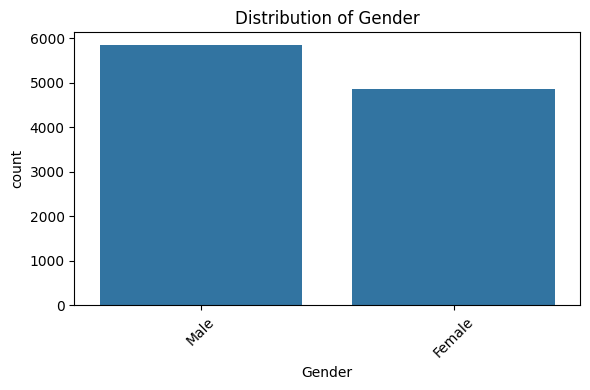

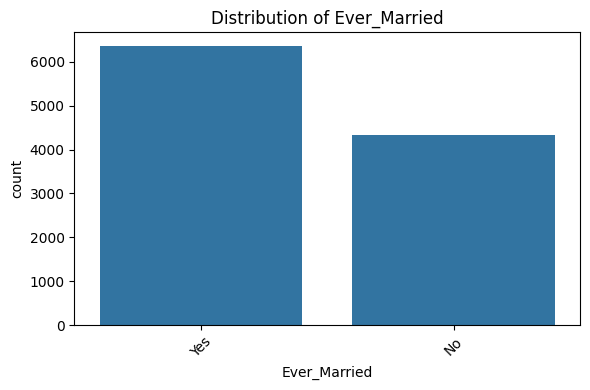

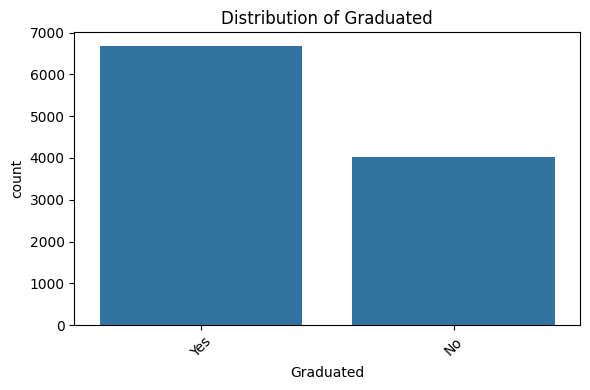

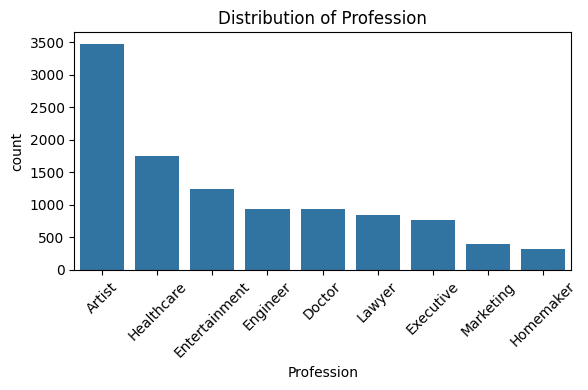

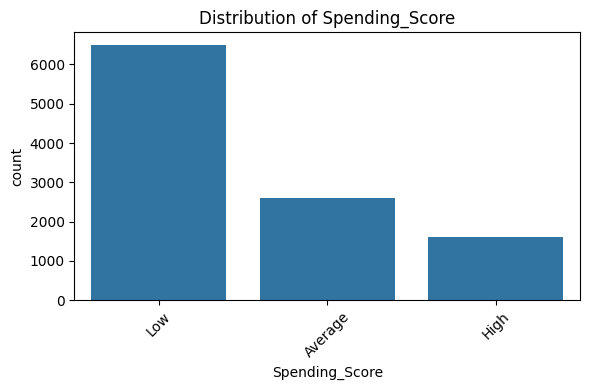

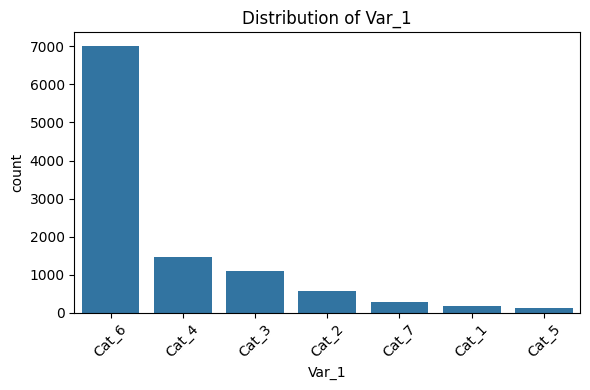

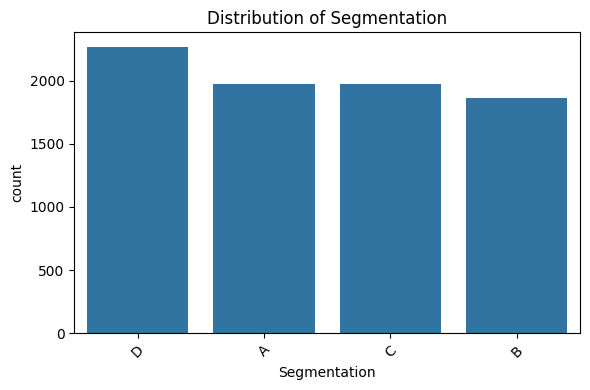

In [ ]:
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=combined_df, x=col, order=combined_df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

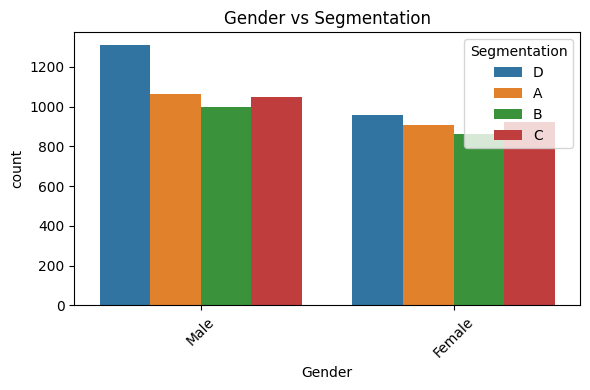

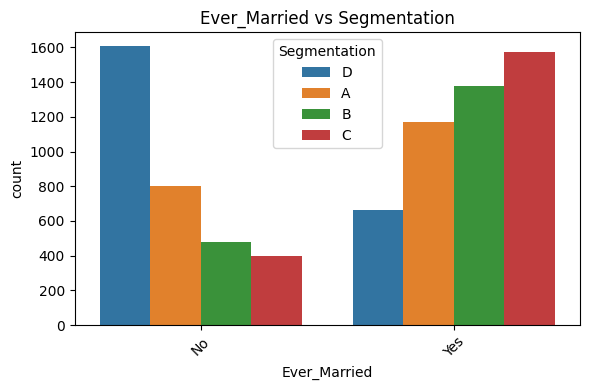

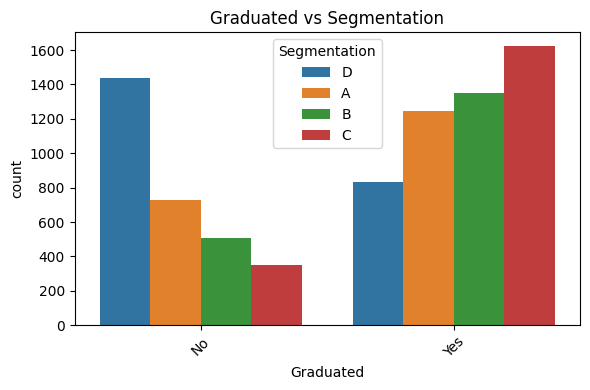

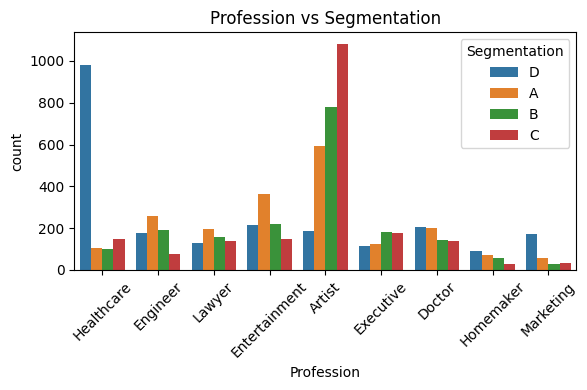

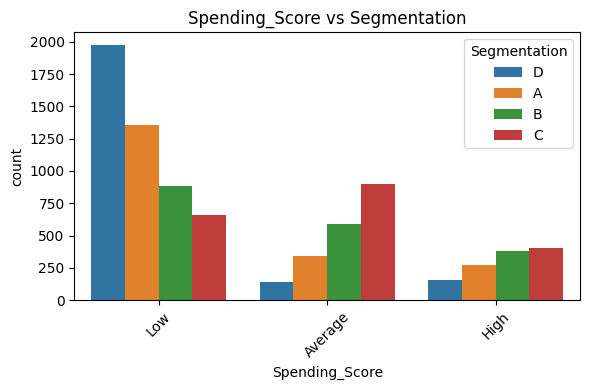

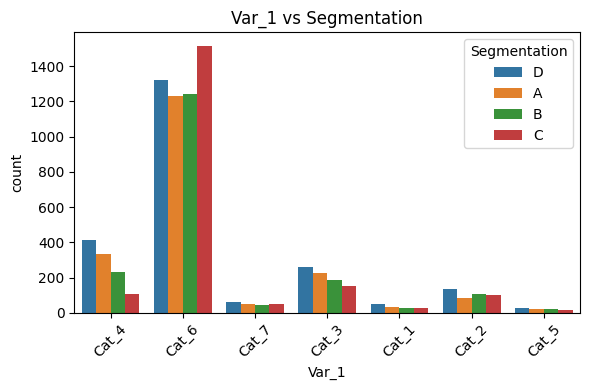

In [ ]:
train_only = combined_df[combined_df['Segmentation'].notna()]

for col in categorical_cols[:-1]:
    plt.figure(figsize=(6,4))
    sns.countplot(data=train_only, x=col, hue='Segmentation')
    plt.title(f'{col} vs Segmentation')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


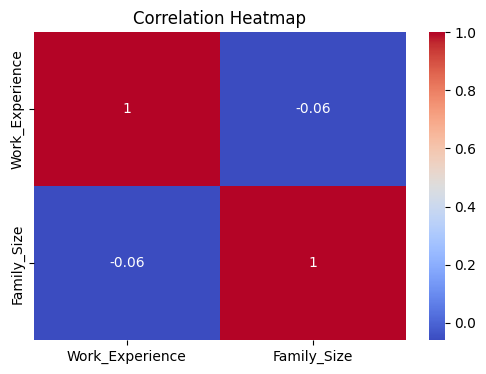

In [ ]:
#Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(train_only[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


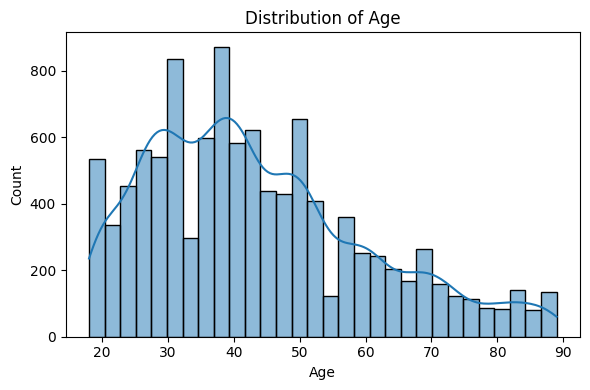

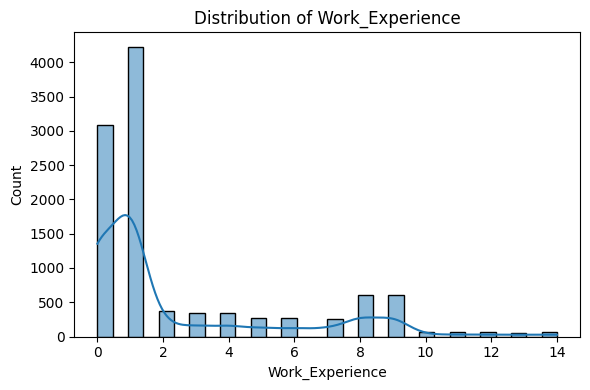

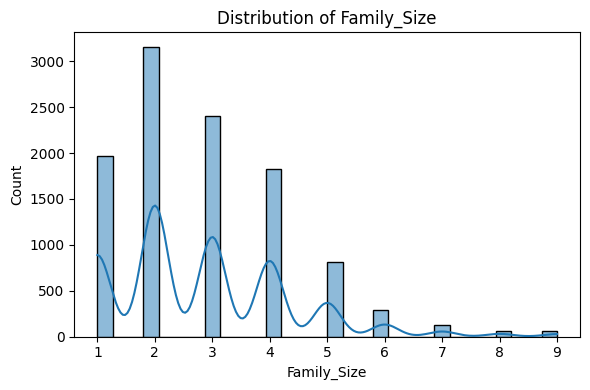

In [ ]:
#Normal Distribution
numerical_cols = ['Age', 'Work_Experience', 'Family_Size']

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(combined_df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()


 Normalize and scale data

In [ ]:
numerical_cols = ['Age', 'Work_Experience', 'Family_Size']

df_scaled = combined_df.copy()


scaler = StandardScaler()

df_scaled[numerical_cols] = scaler.fit_transform(df_scaled[numerical_cols])
print(df_scaled[numerical_cols].head())

        Age  Work_Experience  Family_Size
0 -1.282499        -0.447327     0.764161
1 -0.328606        -0.447327     0.099335
2  1.400325        -0.447327    -1.230315
3  1.400325        -0.755089    -0.565490
4 -0.209369        -0.447327     2.093811


In [ ]:
# Select the scaled features for clustering
features = df_scaled[['Age', 'Work_Experience', 'Family_Size']]

features.head()


,Age,Work_Experience,Family_Size
0,-1.282499,-0.447327,0.764161
1,-0.328606,-0.447327,0.099335
2,1.400325,-0.447327,-1.230315
3,1.400325,-0.755089,-0.565490
4,-0.209369,-0.447327,2.093811


Apply K-Means clustering

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

wcss = []
sil_scores = []
K = range(2, 11)  # Try k = 2 to 10

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(features)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(features, km.labels_))


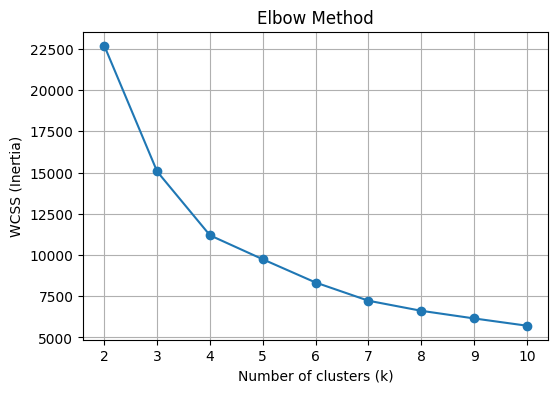

In [ ]:
# Elbow plot
plt.figure(figsize=(6,4))
plt.plot(K, wcss, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method")
plt.grid(True)
plt.show()


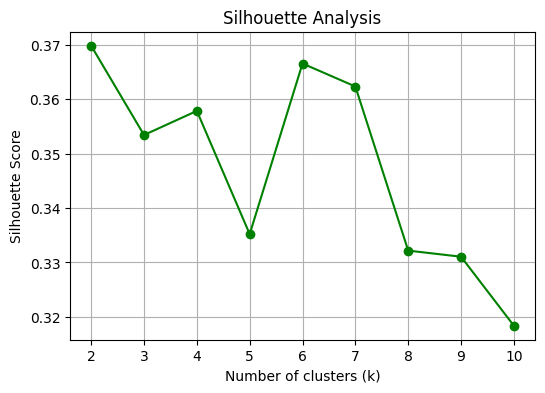

In [ ]:
# Silhouette plot
plt.figure(figsize=(6,4))
plt.plot(K, sil_scores, marker='o', color='green')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.grid(True)
plt.show()


In [ ]:
best_k = 3  # <- Change this if needed
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(features)

# Add cluster labels to df_scaled
df_scaled['Cluster'] = clusters

# View with cluster labels
df_scaled[['Age', 'Work_Experience', 'Family_Size', 'Cluster']].head()


,Age,Work_Experience,Family_Size,Cluster
0,-1.282499,-0.447327,0.764161,2
1,-0.328606,-0.447327,0.099335,2
2,1.400325,-0.447327,-1.230315,1
3,1.400325,-0.755089,-0.565490,1
4,-0.209369,-0.447327,2.093811,2


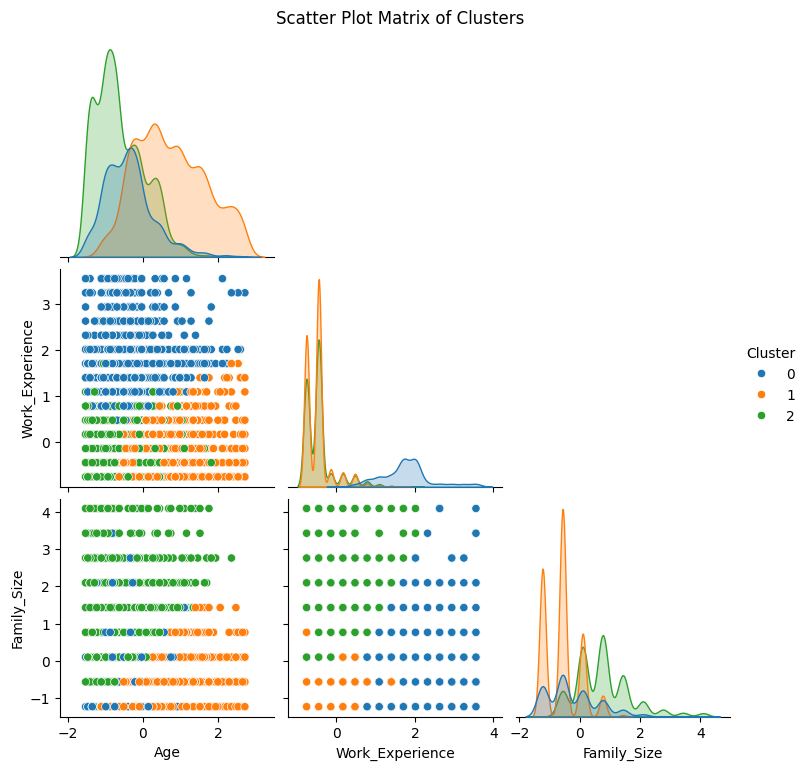

In [ ]:
import seaborn as sns

# Create scatter matrix colored by cluster
sns.pairplot(
    df_scaled,
    vars=['Age', 'Work_Experience', 'Family_Size'],
    hue='Cluster',
    palette='tab10',
    corner=True
)
plt.suptitle("Scatter Plot Matrix of Clusters", y=1.02)
plt.show()


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
components = pca.fit_transform(features)

pca_df = pd.DataFrame(components, columns=['PC1', 'PC2'])
pca_df['Cluster'] = clusters


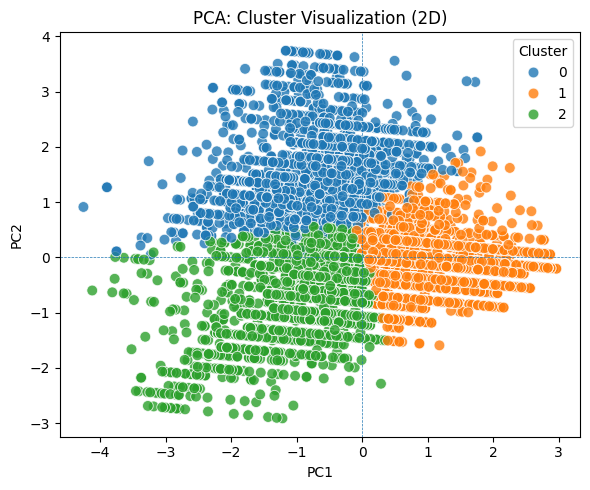

In [ ]:
# Plot PCA result
plt.figure(figsize=(6,5))
sns.scatterplot(
    data=pca_df,
    x='PC1', y='PC2',
    hue='Cluster',
    palette='tab10',
    s=60, alpha=0.8
)
plt.title("PCA: Cluster Visualization (2D)")
plt.axhline(0, ls='--', lw=0.5)
plt.axvline(0, ls='--', lw=0.5)
plt.tight_layout()
plt.show()


Profile each cluster (common traits, spending behavior, etc.)

In [ ]:
# Filter only training rows with segmentation labels
train_only = combined_df[combined_df['Segmentation'].notna()]

# Convert Segmentation to string if needed
train_only['Segmentation'] = train_only['Segmentation'].astype(str)

# Group by Segmentation
profile_summary = train_only.groupby("Segmentation").agg({
    "Gender": pd.Series.mode,
    "Ever_Married": pd.Series.mode,
    "Age": "median",
    "Graduated": pd.Series.mode,
    "Profession": pd.Series.mode,
    "Spending_Score": pd.Series.mode,
    "Work_Experience": "median",
    "Family_Size": "median"
}).reset_index()

print(profile_summary)


  Segmentation Gender Ever_Married   Age Graduated  Profession Spending_Score  \
0            A   Male          Yes  41.0       Yes      Artist            Low   
1            B   Male          Yes  46.0       Yes      Artist            Low   
2            C   Male          Yes  49.0       Yes      Artist        Average   
3            D   Male           No  29.0        No  Healthcare            Low   

   Work_Experience  Family_Size  
0              1.0          2.0  
1              1.0          2.0  
2              1.0          3.0  
3              1.0          3.0  


/tmp/ipython-input-29-3260444659.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_only['Segmentation'] = train_only['Segmentation'].astype(str)


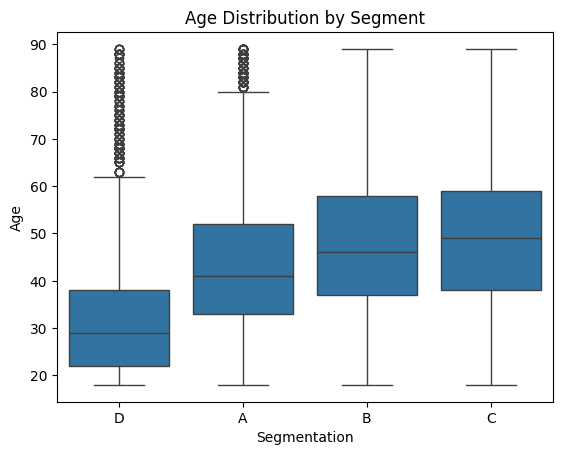

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=train_only, x='Segmentation', y='Age')
plt.title("Age Distribution by Segment")
plt.show()


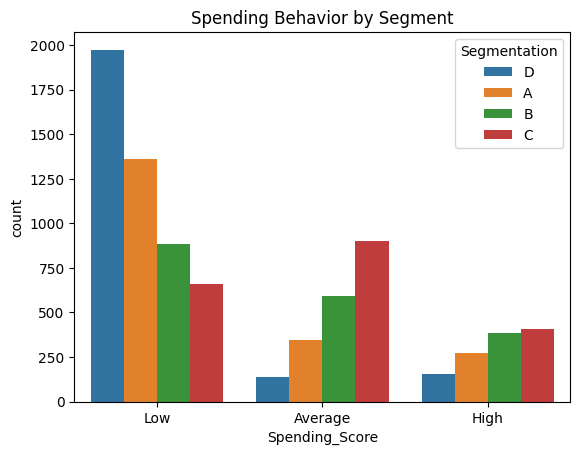

In [ ]:
sns.countplot(data=train_only, x='Spending_Score', hue='Segmentation')
plt.title("Spending Behavior by Segment")
plt.show()


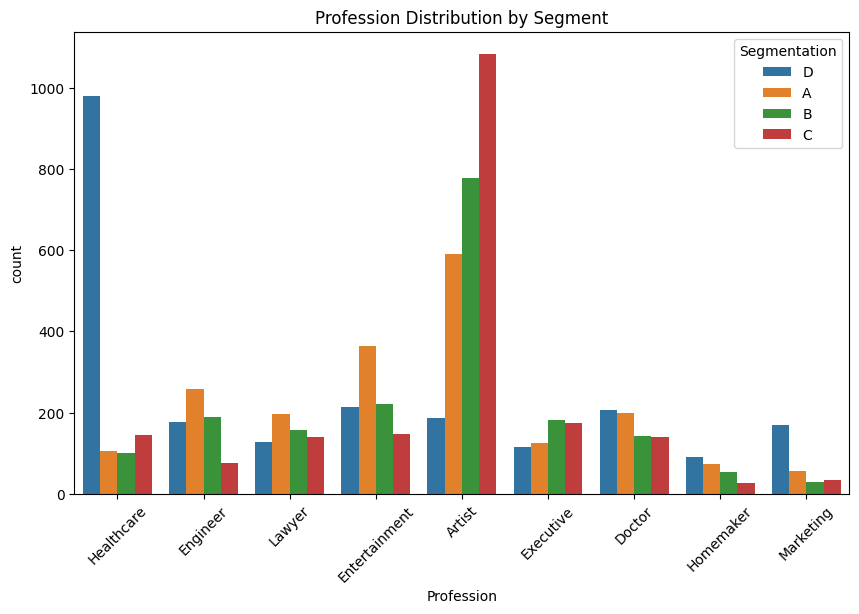

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(data=train_only, x='Profession', hue='Segmentation')
plt.title("Profession Distribution by Segment")
plt.xticks(rotation=45)
plt.show()
